<a href="https://colab.research.google.com/github/jadenfix/machine_learning/blob/financial-machine-learning/physics_%26_DL_%26_ML_%26_econometrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
from datetime import datetime

# Path to the file
file_path = '/content/^spx_d_daily.csv'

# Step 1: Read the file without headers
df_raw = pd.read_csv(file_path, header=None, names=["Date", "Open", "High", "Low", "Close", "Volume"])

# Step 2: Function to handle both date formats
def parse_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    except:
        try:
            # Handle cases like 1/2/00 → assume year 2000+
            dt = datetime.strptime(date_str, '%m/%d/%y')
            # Optional: Force to 1900s if needed
            if dt.year < 100:
                dt = dt.replace(year=dt.year + 1900)
            return dt
        except:
            return pd.NaT

# Step 3: Apply date parsing
df_raw['Date'] = df_raw['Date'].apply(parse_date)

# Step 4: Drop rows with unparseable dates (if any)
df_clean = df_raw.dropna(subset=['Date']).reset_index(drop=True)

# Optional: Sort by date
df_clean = df_clean.sort_values(by='Date').reset_index(drop=True)

# Display the cleaned DataFrame
print(df_clean.head())
print(df_clean.tail())

        Date  Open  High   Low Close Volume
0 1789-05-01  0.51  0.51  0.51  0.51      0
1 1789-06-01  0.51  0.51  0.51  0.51      0
2 1789-07-01   0.5   0.5   0.5   0.5      0
3 1789-08-01   0.5  0.51   0.5  0.51      0
4 1789-09-01  0.51  0.51   0.5  0.51      0
            Date     Open     High      Low    Close      Volume
39239 2024-07-18  5608.56  5614.05  5522.81  5544.59  2935073001
39240 2024-07-19  5543.37   5557.5  5497.04     5505  2649224224
39241 2024-07-22  5544.54  5570.36  5529.04  5564.41  2525550865
39242 2024-07-23   5565.3  5585.34   5550.9  5555.74  2425966152
39243 2024-07-24  5505.84  5508.04  5419.98  5427.13  3041996728


Base data 'df_clean' found. Proceeding with preparation and modeling.

--- Fitting GARCH(1,1) on Training Data ---
GARCH fitting complete.
GARCH volatility added to DataFrame.

--- Performing Feature Engineering ---
Added 3 lags of GARCH volatility.
DataFrame shape after feature engineering & NaN drop: (6944, 18)

Using features: ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Rolling_Mean', 'Rolling_Std', 'Volume_Change', 'GARCH_Vol_Lag_1', 'GARCH_Vol_Lag_2', 'GARCH_Vol_Lag_3']

Training set size: 5555
Test set size: 1389

--- Scaling Data ---

--- Training AdaBoost ---
AdaBoost training complete.

--- Training XGBoost ---
XGBoost training complete.

--- Predicting Last Month ---
Identifying data for last month: 2017-08
Data range in index: 2017-08-01 00:00:00 to 2017-08-21 00:00:00
Selected 15 data points for the last month.

--- Evaluating Last Month Predictions ---
AdaBoost - RMSE: 0.006177, MAE: 0.003929
XGBoost  - RMSE: 0.006212, MAE: 0.003710


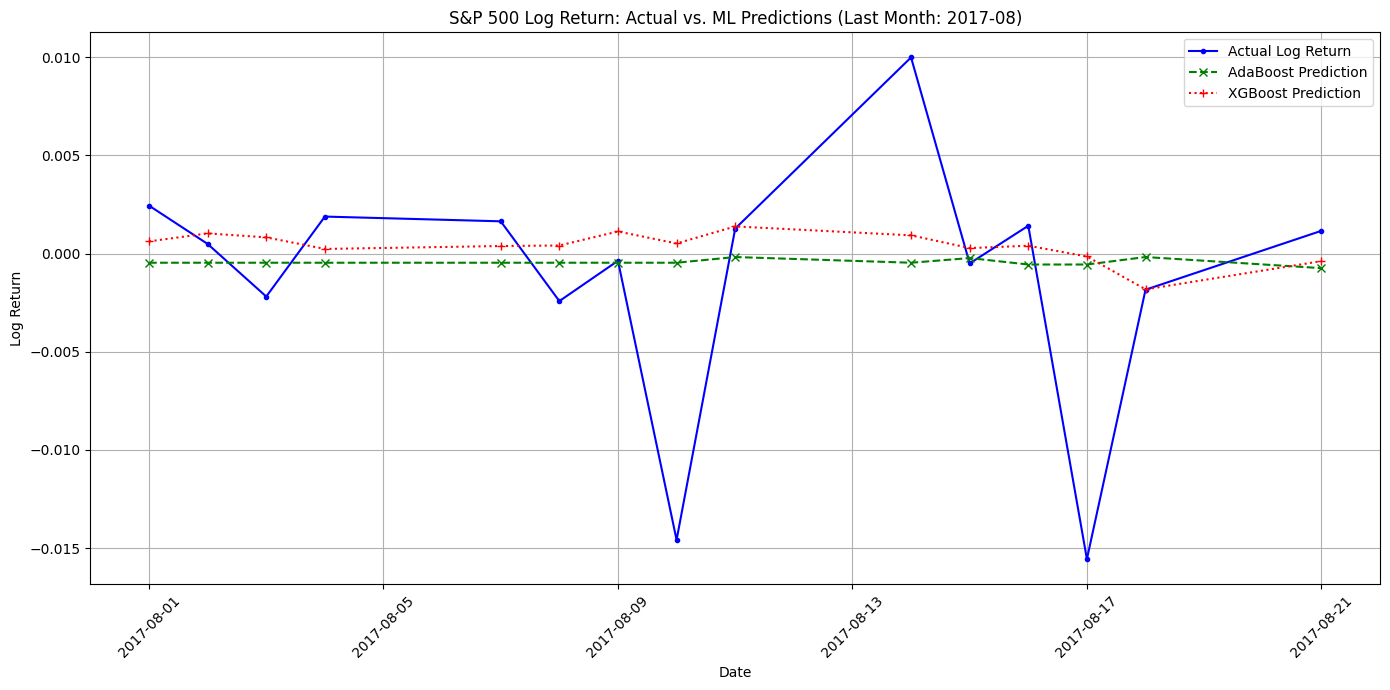

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model # Import the GARCH model function
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor
import xgboost as xgb # Import XGBoost
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# --- Prerequisites (Ensure these are available from previous steps) ---
# df_clean: DataFrame after initial loading and date parsing
# Also assumes the basic data prep steps (filtering date, calculating log return)
# were done previously to create 'df' and 'log_returns_train' etc.
# If not, uncomment and adapt the prep steps below.

# --- Check if prerequisites exist (Example check) ---
required_vars = ['df_clean'] # Need the base cleaned data
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please ensure the initial data loading and cleaning steps have been run successfully.")
    # --- Minimal Data Prep (Repeat if needed) ---
    # if 'df_clean' in locals() or 'df_clean' in globals():
    #     if 'Date' in df_clean.columns: df_clean = df_clean.set_index('Date')
    #     if not isinstance(df_clean.index, pd.DatetimeIndex): df_clean.index = pd.to_datetime(df_clean.index)
    #     numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    #     for col in numeric_cols: df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    #     df_clean.dropna(subset=['Close', 'Volume'], inplace=True)
    #     start_date_filter = "1990-01-01"
    #     df_clean.index = pd.to_datetime(df_clean.index)
    #     df = df_clean[df_clean.index >= start_date_filter].copy()
    #     df.sort_index(inplace=True)
    #     df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    #     df.dropna(subset=['Log_Return'], inplace=True)
    # else:
    #     raise ValueError("df_clean not found. Cannot proceed.")

else:
    print("Base data 'df_clean' found. Proceeding with preparation and modeling.")
    # --- Repeat Minimal Data Prep Steps ---
    if 'Date' in df_clean.columns: df_clean = df_clean.set_index('Date')
    if not isinstance(df_clean.index, pd.DatetimeIndex): df_clean.index = pd.to_datetime(df_clean.index)
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in numeric_cols: df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    df_clean.dropna(subset=['Close', 'Volume'], inplace=True)
    start_date_filter = "1990-01-01"
    df_clean.index = pd.to_datetime(df_clean.index)
    df = df_clean[df_clean.index >= start_date_filter].copy()
    df.sort_index(inplace=True)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df.dropna(subset=['Log_Return'], inplace=True)


warnings.filterwarnings("ignore") # Suppress warnings

try:
    # --- 1. Fit GARCH and Extract Conditional Volatility ---
    print("\n--- Fitting GARCH(1,1) on Training Data ---")
    # Split log returns for GARCH fitting (use same split point as before)
    test_size = 0.2
    split_point_garch = int(len(df) * (1 - test_size))
    log_returns_train_garch = df['Log_Return'].iloc[:split_point_garch]

    # Scale returns for GARCH fitting
    scaled_log_returns_train = log_returns_train_garch * 100

    garch = arch_model(scaled_log_returns_train, vol='Garch', p=1, q=1, dist='Normal')
    garch_results = garch.fit(update_freq=0, disp='off') # Fit quietly
    print("GARCH fitting complete.")
    # print(garch_results.summary()) # Optional: view summary

    # Get conditional volatility from the fitted model (scaled)
    cond_vol_scaled = garch_results.conditional_volatility

    # Scale back volatility and align with the original df index (training part)
    # Divide by 100 as we multiplied returns by 100
    cond_vol = cond_vol_scaled / 100.0
    cond_vol.name = 'GARCH_Volatility'

    # Add GARCH volatility to the main DataFrame (align by index)
    df = df.join(cond_vol) # Join based on index
    print("GARCH volatility added to DataFrame.")
    # print(df[['Log_Return', 'GARCH_Volatility']].head()) # Check join


    # --- 2. Feature Engineering (Including GARCH Volatility) ---
    print("\n--- Performing Feature Engineering ---")
    lags = 5
    rolling_window = 20
    garch_lags = 3 # Number of lags for GARCH volatility feature

    # Original features
    for i in range(1, lags + 1):
        df[f'Lag_{i}'] = df['Log_Return'].shift(i)
    df['Rolling_Mean'] = df['Log_Return'].shift(1).rolling(window=rolling_window).mean()
    df['Rolling_Std'] = df['Log_Return'].shift(1).rolling(window=rolling_window).std()
    epsilon = 1e-10
    df['Volume_Change'] = np.log((df['Volume'] + epsilon) / (df['Volume'].shift(1) + epsilon))

    # Add lagged GARCH volatility feature
    if 'GARCH_Volatility' in df.columns:
        for i in range(1, garch_lags + 1):
             # Lag the volatility from the *training* fit
             df[f'GARCH_Vol_Lag_{i}'] = df['GARCH_Volatility'].shift(i)
        print(f"Added {garch_lags} lags of GARCH volatility.")
    else:
        print("Warning: GARCH_Volatility column not found after join.")


    # Replace inf/-inf and drop NaNs introduced by feature engineering
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    print(f"DataFrame shape after feature engineering & NaN drop: {df.shape}")


    # --- 3. Define Features and Target, Split Data ---
    # Update feature list
    features = [f'Lag_{i}' for i in range(1, lags + 1)] + \
               ['Rolling_Mean', 'Rolling_Std', 'Volume_Change'] + \
               [f'GARCH_Vol_Lag_{i}' for i in range(1, garch_lags + 1)]

    target = 'Log_Return'

    # Ensure all feature columns exist
    features = [f for f in features if f in df.columns]
    if not features:
        raise ValueError("No feature columns remaining after processing!")
    print(f"\nUsing features: {features}")

    X = df[features]
    y = df[target]

    # Split Data (Chronological) using the same proportion
    split_point = int(len(df) * (1 - test_size))
    if split_point <= 0 or split_point >= len(df):
         raise ValueError(f"Calculated split_point ({split_point}) is invalid for DataFrame length ({len(df)}).")

    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

    print(f"\nTraining set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")


    # --- 4. Scale Data ---
    print("\n--- Scaling Data ---")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # --- 5. Train XGBoost and AdaBoost ---
    print("\n--- Training AdaBoost ---")
    # AdaBoost often uses simpler base estimators
    ada_model = AdaBoostRegressor(
        estimator=None, # Default is DecisionTreeRegressor(max_depth=3)
        n_estimators=100, # Number of boosting stages
        learning_rate=0.1,
        loss='square', # 'linear', 'square', 'exponential'
        random_state=42
    )
    ada_model.fit(X_train_scaled, y_train)
    print("AdaBoost training complete.")

    print("\n--- Training XGBoost ---")
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Regression task
        n_estimators=200,             # Number of boosting rounds
        learning_rate=0.05,           # Step size shrinkage
        max_depth=5,                  # Max depth of a tree
        subsample=0.8,                # Fraction of samples used per tree
        colsample_bytree=0.8,         # Fraction of features used per tree
        random_state=42,
        n_jobs=-1                     # Use all available CPU cores
    )
    xgb_model.fit(X_train_scaled, y_train)
    print("XGBoost training complete.")


    # --- 6. Predict Last Month ---
    print("\n--- Predicting Last Month ---")
    # Identify last month's data in the *final processed* df
    last_date = df.index.max()
    last_year = last_date.year
    last_month_num = last_date.month
    last_month_dates = df.index[(df.index.year == last_year) & (df.index.month == last_month_num)]

    if last_month_dates.empty:
        print("Error: No data found for the identified last month in the final processed DataFrame.")
    else:
        actual_start_last_month = last_month_dates.min()
        actual_end_last_month = last_month_dates.max()
        print(f"Identifying data for last month: {last_year}-{last_month_num:02d}")
        print(f"Data range in index: {actual_start_last_month} to {actual_end_last_month}")

        # Select features for the last month
        X_last_month = df.loc[actual_start_last_month:actual_end_last_month, features]
        y_last_month = df.loc[actual_start_last_month:actual_end_last_month, target]

        if X_last_month.empty:
             print("Error: No feature data selected for the last month.")
        else:
            print(f"Selected {len(X_last_month)} data points for the last month.")
            # Scale features using the fitted scaler
            X_last_month_scaled = scaler.transform(X_last_month)

            # Predict with AdaBoost
            ada_predictions_last_month = ada_model.predict(X_last_month_scaled)
            ada_predictions_last_month = pd.Series(ada_predictions_last_month, index=y_last_month.index)

            # Predict with XGBoost
            xgb_predictions_last_month = xgb_model.predict(X_last_month_scaled)
            xgb_predictions_last_month = pd.Series(xgb_predictions_last_month, index=y_last_month.index)

            # --- 7. Evaluate and Plot Last Month ---
            print("\n--- Evaluating Last Month Predictions ---")
            ada_rmse_lm = np.sqrt(mean_squared_error(y_last_month, ada_predictions_last_month))
            ada_mae_lm = mean_absolute_error(y_last_month, ada_predictions_last_month)
            xgb_rmse_lm = np.sqrt(mean_squared_error(y_last_month, xgb_predictions_last_month))
            xgb_mae_lm = mean_absolute_error(y_last_month, xgb_predictions_last_month)

            print(f"AdaBoost - RMSE: {ada_rmse_lm:.6f}, MAE: {ada_mae_lm:.6f}")
            print(f"XGBoost  - RMSE: {xgb_rmse_lm:.6f}, MAE: {xgb_mae_lm:.6f}")

            # Plotting
            plt.figure(figsize=(14, 7))
            plt.plot(y_last_month.index, y_last_month, label='Actual Log Return', marker='.', linestyle='-', color='blue')
            plt.plot(ada_predictions_last_month.index, ada_predictions_last_month, label='AdaBoost Prediction', marker='x', linestyle='--', color='green')
            plt.plot(xgb_predictions_last_month.index, xgb_predictions_last_month, label='XGBoost Prediction', marker='+', linestyle=':', color='red')
            plt.title(f'S&P 500 Log Return: Actual vs. ML Predictions (Last Month: {last_year}-{last_month_num:02d})')
            plt.xlabel('Date')
            plt.ylabel('Log Return')
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

except NameError as ne:
     print(f"A required variable is missing: {ne}")
     print("Please ensure the initial data loading and preparation steps were completed.")
except ImportError as ie:
     print(f"An essential library is missing: {ie}")
     print("Please install required libraries (arch, xgboost).")
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()



Comparing various methods


Original dtypes:
Open      object
High      object
Low       object
Close     object
Volume    object
dtype: object

New dtypes after to_numeric:
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

NaN counts after coercion:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Shape after handling NaNs: (39244, 5)
Training set size: 6948
Test set size: 1737
Training period: 1990-01-31 00:00:00 to 2017-08-25 00:00:00
Test period: 2017-08-28 00:00:00 to 2024-07-24 00:00:00

--- Training ARIMA ---
ARIMA failed: Lengths must match to compare

--- Training Random Forest ---

--- Training LSTM ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,051 (125.20 KB)

 Trainable params: 32,051 (125.20 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Training Finished.
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- Model Evaluation (Test Set) ---
No valid predictions for ARIMA to evaluate.
Random Forest - RMSE: 0.012557, MAE: 0.008044 (evaluated on 1737 points)
LSTM - RMSE: 0.012371, MAE: 0.007968 (evaluated on 1737 points)

--- Comparison Summary ---
                   RMSE       MAE
Random Forest  0.012557  0.008044
LSTM           0.012371  0.007968


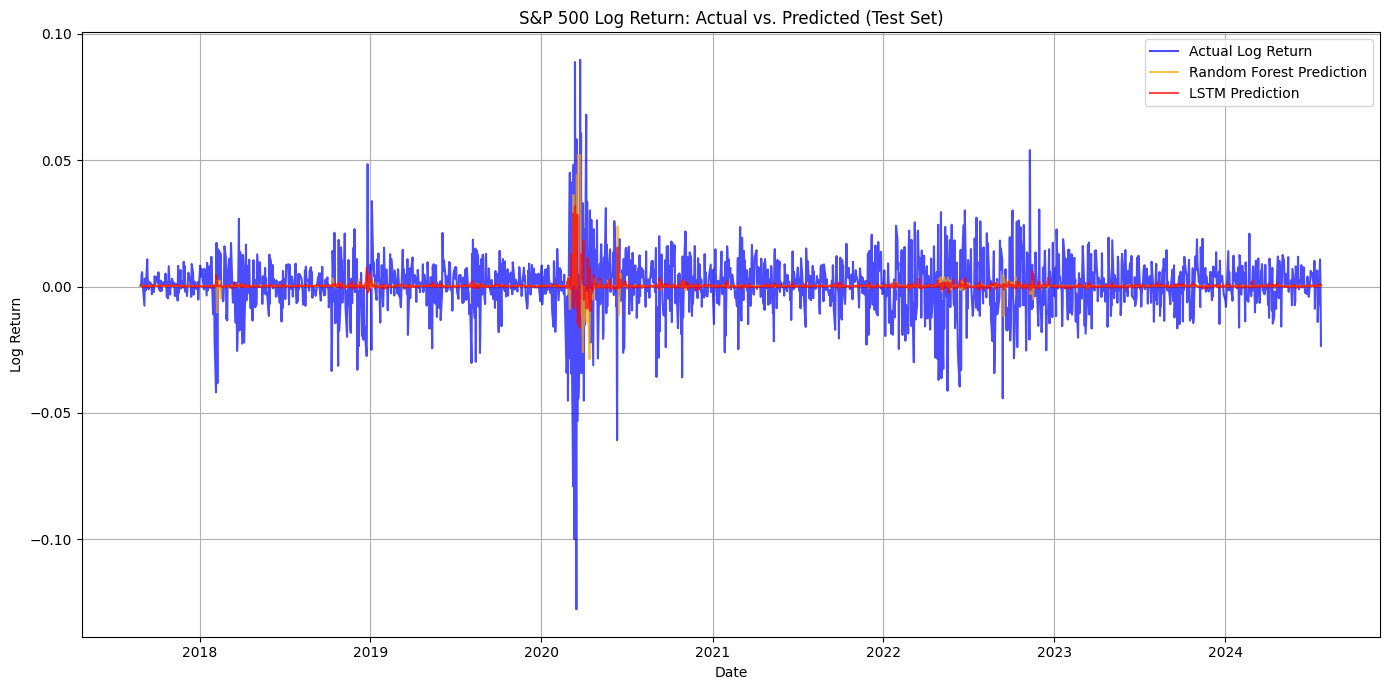

In [12]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# --- Assume df_clean is your pre-loaded DataFrame ---
# df_clean should have columns: Date (parsed), Open, High, Low, Close, Volume

# --- 1. Data Preparation ---

# Make sure 'Date' is the index and is datetime type
if 'Date' in df_clean.columns:
    df_clean = df_clean.set_index('Date')
if not isinstance(df_clean.index, pd.DatetimeIndex):
    # If index is not datetime after set_index, try converting it
    try:
        df_clean.index = pd.to_datetime(df_clean.index)
        print("Index converted to DatetimeIndex.")
    except Exception as e:
        print(f"Error converting index to DatetimeIndex: {e}")
        # Handle error appropriately, maybe exit or drop problematic index values

# *** Add Step: Convert Price/Volume Columns to Numeric ***
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
print(f"\nOriginal dtypes:\n{df_clean[numeric_cols].dtypes}")

for col in numeric_cols:
    # errors='coerce' will turn anything that can't be converted into NaN
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(f"\nNew dtypes after to_numeric:\n{df_clean[numeric_cols].dtypes}")

# *** Add Step: Handle potential NaNs from coercion ***
# Check how many NaNs were introduced
print(f"\nNaN counts after coercion:\n{df_clean[numeric_cols].isnull().sum()}")
# Option 1: Drop rows with NaNs in essential columns (Close, Volume needed for calcs)
df_clean.dropna(subset=['Close', 'Volume'], inplace=True)
# Option 2: Imputation (e.g., ffill - use carefully)
# df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method='ffill')
# df_clean.dropna(inplace=True) # Drop any remaining NaNs at the start

print(f"\nShape after handling NaNs: {df_clean.shape}")


# Filter Data to a more recent period (e.g., starting 1990)
start_date_filter = "1990-01-01"
# Ensure index is datetime before comparison
df_clean.index = pd.to_datetime(df_clean.index)
df = df_clean[df_clean.index >= start_date_filter].copy()


# Ensure data is sorted by date (should be already, but good practice)
df.sort_index(inplace=True)

# Calculate Log Returns (Target Variable) - Should work now
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row with NaN log return
df.dropna(subset=['Log_Return'], inplace=True)

# --- Feature Engineering (for ML/DL) ---
lags = 5
rolling_window = 20 # Example window size

for i in range(1, lags + 1):
    df[f'Lag_{i}'] = df['Log_Return'].shift(i)

df['Rolling_Mean'] = df['Log_Return'].shift(1).rolling(window=rolling_window).mean()
df['Rolling_Std'] = df['Log_Return'].shift(1).rolling(window=rolling_window).std()

# Add Volume change feature (example) - Should work now
# Add a small epsilon to avoid log(0) if volume can be 0
epsilon = 1e-10
df['Volume_Change'] = np.log((df['Volume'] + epsilon) / (df['Volume'].shift(1) + epsilon))
# Replace infinite values that might arise from log(0) or division by zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)


# Drop rows with NaNs created by lags and rolling features
df.dropna(inplace=True)

# Define features (X) and target (y)
features = [f'Lag_{i}' for i in range(1, lags + 1)] + ['Rolling_Mean', 'Rolling_Std', 'Volume_Change']
target = 'Log_Return'

# Ensure all feature columns exist after potential drops
features = [f for f in features if f in df.columns]
if not features:
    raise ValueError("No feature columns remaining after processing!")


X = df[features]
y = df[target]

# --- Split Data (Chronological) ---
test_size = 0.2 # Use last 20% for testing
split_index = int(len(df) * (1 - test_size))

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Also keep the original log returns for ARIMA
log_returns_train = df['Log_Return'].iloc[:split_index]
log_returns_test = df['Log_Return'].iloc[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period: {X_test.index.min()} to {X_test.index.max()}")


# --- Scaling (for ML/DL) ---
from sklearn.preprocessing import StandardScaler

# Check if X_train is empty before scaling
if X_train.empty:
     raise ValueError("X_train is empty after preprocessing and splitting. Check date filter or NaN handling.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note: Target variable (y) is usually NOT scaled for standard regression metrics,
# but might be scaled for certain neural network architectures / loss functions.
# We will keep y unscaled here.


# --- 2. Model Implementation Examples ---

# == A. Econometric / Stochastic (ARIMA) ==
print("\n--- Training ARIMA ---")
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Suppress convergence warnings etc.

try:
    # Example order (p,d,q) - requires tuning based on ACF/PACF plots or auto_arima
    arima_order = (5, 0, 0) # Example: AR(5) model on log returns (assuming d=0 as returns are likely stationary)
    arima_model = ARIMA(log_returns_train, order=arima_order, freq='B') # Specify business day frequency if applicable
    arima_fit = arima_model.fit()
    print(arima_fit.summary())

    # Make predictions on the test set (one-step ahead)
    start_pred_index = log_returns_test.index[0] # Start predicting from the first date in the test set
    end_pred_index = log_returns_test.index[-1] # Predict until the last date in the test set

    # Use predict for in-sample and out-of-sample forecasting based on index
    arima_predictions = arima_fit.predict(start=start_pred_index, end=end_pred_index)
    # Align predictions with the test set index (should match if start/end are correct)
    # arima_predictions.index = log_returns_test.index # Often not needed if predict uses dates

except Exception as e:
    print(f"ARIMA failed: {e}")
    arima_predictions = pd.Series(np.nan, index=log_returns_test.index) # Placeholder

# == B. Machine Learning (Random Forest) ==
print("\n--- Training Random Forest ---")
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10, min_samples_split=10)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_predictions = pd.Series(rf_predictions, index=y_test.index)


# == C. Deep Learning (LSTM) ==
print("\n--- Training LSTM ---")
# Check TensorFlow installation
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("TensorFlow not found. Skipping LSTM.")
    lstm_predictions = pd.Series(np.nan, index=y_test.index) # Placeholder
else:
    # Reshape data for LSTM: [samples, timesteps, features]
    n_features = X_train_scaled.shape[1]
    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, n_features))
    X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, n_features))

    lstm_model = keras.Sequential(
        [
            layers.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
            layers.LSTM(50, activation='relu', return_sequences=True), # Can stack LSTMs
            layers.Dropout(0.2),
            layers.LSTM(50, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(1) # Output layer for regression
        ]
    )

    lstm_model.compile(optimizer='adam', loss='mse') # Mean Squared Error loss
    lstm_model.summary()

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model (use a validation split from the training data)
    history = lstm_model.fit(
        X_train_lstm, y_train,
        epochs=50, # Adjust epochs
        batch_size=32, # Adjust batch size
        validation_split=0.1, # Use 10% of training data for validation
        callbacks=[early_stopping],
        verbose=0 # Set to 0 for less output, 1 for progress bar
    )
    print("LSTM Training Finished.")

    # Predict on test data
    lstm_predictions_scaled = lstm_model.predict(X_test_lstm)
    lstm_predictions = pd.Series(lstm_predictions_scaled.flatten(), index=y_test.index)


# --- 4. Evaluation and Comparison ---
print("\n--- Model Evaluation (Test Set) ---")
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = {}

def evaluate_model(name, predictions, actual):
    # Drop NaNs that might exist in predictions (e.g., from failed ARIMA)
    valid_preds = predictions.dropna()
    valid_actual = actual[valid_preds.index] # Align actual values
    if len(valid_preds) == 0:
        print(f"No valid predictions for {name} to evaluate.")
        results[name] = {'RMSE': np.nan, 'MAE': np.nan}
        return

    rmse = np.sqrt(mean_squared_error(valid_actual, valid_preds))
    mae = mean_absolute_error(valid_actual, valid_preds)
    results[name] = {'RMSE': rmse, 'MAE': mae}
    print(f"{name} - RMSE: {rmse:.6f}, MAE: {mae:.6f} (evaluated on {len(valid_preds)} points)")

# Evaluate models
evaluate_model("ARIMA", arima_predictions, y_test)
evaluate_model("Random Forest", rf_predictions, y_test)
evaluate_model("LSTM", lstm_predictions, y_test)


print("\n--- Comparison Summary ---")
results_df = pd.DataFrame(results).T.dropna(how='all') # Drop rows where all values are NaN
print(results_df)

# --- Plotting Example (Actual vs. Predicted for one model) ---
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Log Return', alpha=0.7, color='blue')

# Plot predictions only if they exist and are not all NaN
if 'Random Forest' in results and not rf_predictions.isnull().all():
    plt.plot(rf_predictions.index, rf_predictions, label='Random Forest Prediction', alpha=0.7, color='orange')
if 'ARIMA' in results and not arima_predictions.isnull().all():
     plt.plot(arima_predictions.index, arima_predictions, label='ARIMA Prediction', alpha=0.7, color='green')
if 'LSTM' in results and not lstm_predictions.isnull().all():
     plt.plot(lstm_predictions.index, lstm_predictions, label='LSTM Prediction', alpha=0.7, color='red')


plt.title('S&P 500 Log Return: Actual vs. Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


LTSM Method (Not Great)

Prerequisites found. Proceeding with last month prediction.
Identifying data for last month: 2024-07
Data range in index: 2024-07-01 00:00:00 to 2024-07-24 00:00:00
Selected 17 data points for the last month.

--- Predicting with LSTM for Last Month ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Evaluation for Last Month (2024-07):
LSTM RMSE: 0.009016
LSTM MAE:  0.007142


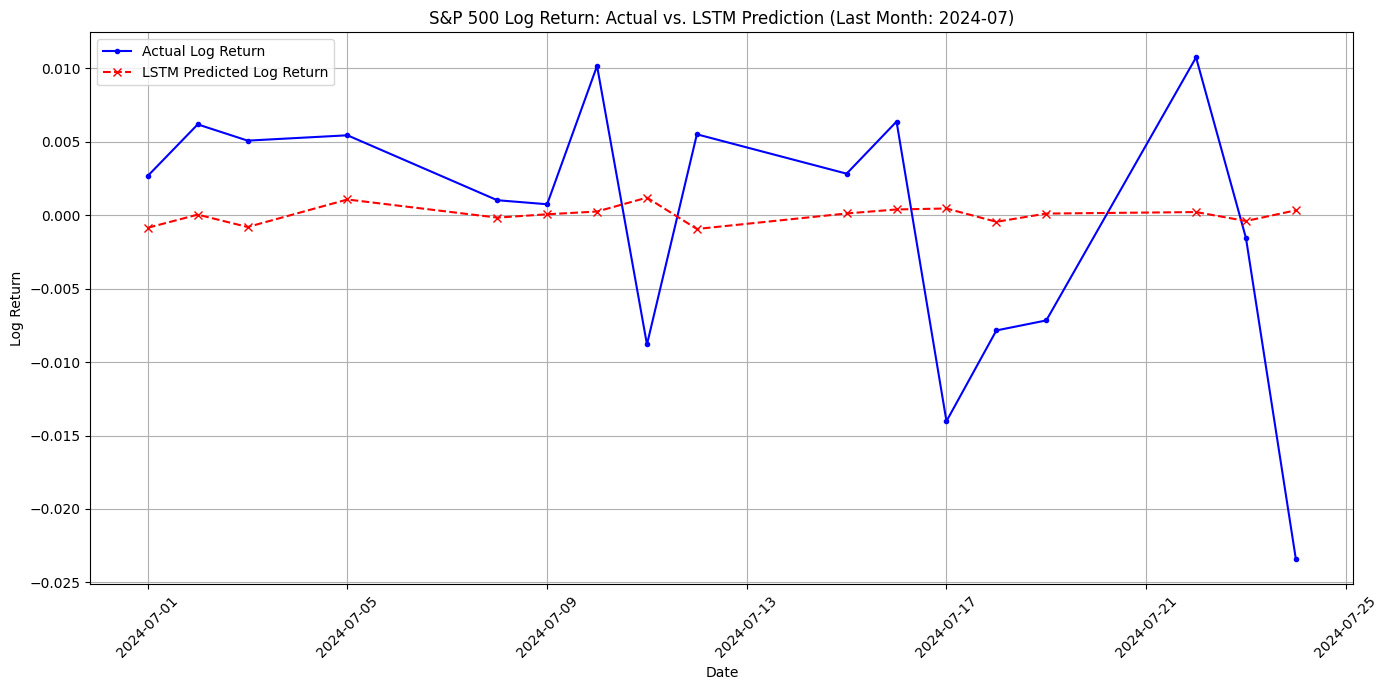

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# Assuming tensorflow, keras, layers, EarlyStopping are imported if needed for retraining
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.callbacks import EarlyStopping


# --- Prerequisites (Ensure these are available from previous steps) ---
# df: DataFrame after preprocessing, feature engineering, and NaN removal
# scaler: StandardScaler object already fitted on X_train_scaled
# lstm_model: Trained Keras LSTM model object
# features: List of feature column names used for training
# target: Name of the target column ('Log_Return')
# X_train, y_train, X_test, y_test: Data splits (needed if retraining)

# --- Check if prerequisites exist (Example check) ---
required_vars = ['df', 'scaler', 'lstm_model', 'features', 'target', 'y_test']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please ensure the previous code block defining and training the models has been run successfully.")
    # You might need to re-run the previous cell or relevant parts here
    # For example:
    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train) # Refit scaler if needed
    # # ... retrain LSTM model if needed ...

else:
    print("Prerequisites found. Proceeding with last month prediction.")

    # --- 1. Identify Last Month's Data ---
    try:
        last_date = df.index.max()
        # Get the year and month of the last date
        last_year = last_date.year
        last_month_num = last_date.month

        # Create start and end timestamps for the last month
        start_last_month = pd.Timestamp(f"{last_year}-{last_month_num:02d}-01")
        # Find the actual first and last date within that month present in the data
        last_month_dates = df.index[(df.index.year == last_year) & (df.index.month == last_month_num)]

        if last_month_dates.empty:
            print("Error: No data found for the identified last month.")
        else:
            actual_start_last_month = last_month_dates.min()
            actual_end_last_month = last_month_dates.max()
            print(f"Identifying data for last month: {last_year}-{last_month_num:02d}")
            print(f"Data range in index: {actual_start_last_month} to {actual_end_last_month}")

            # Select features (X) and actual target (y) for the last month
            X_last_month = df.loc[actual_start_last_month:actual_end_last_month, features]
            y_last_month = df.loc[actual_start_last_month:actual_end_last_month, target]

            if X_last_month.empty:
                 print("Error: No feature data selected for the last month.")
            else:
                print(f"Selected {len(X_last_month)} data points for the last month.")

                # --- 2. Prepare Data for LSTM Prediction ---
                # Scale the features using the *already fitted* scaler
                X_last_month_scaled = scaler.transform(X_last_month)

                # Reshape data for LSTM: [samples, timesteps, features]
                # Using timesteps=1 as per the previous model structure
                n_features_lm = X_last_month_scaled.shape[1]
                X_last_month_lstm = X_last_month_scaled.reshape((X_last_month_scaled.shape[0], 1, n_features_lm))

                # --- 3. Predict using the Trained LSTM Model ---
                print("\n--- Predicting with LSTM for Last Month ---")
                lstm_predictions_last_month_scaled = lstm_model.predict(X_last_month_lstm)

                # Reshape predictions back to 1D and create a pandas Series
                lstm_predictions_last_month = pd.Series(lstm_predictions_last_month_scaled.flatten(), index=y_last_month.index)

                # --- 4. Evaluate and Plot for the Last Month ---
                from sklearn.metrics import mean_squared_error, mean_absolute_error

                rmse_lm = np.sqrt(mean_squared_error(y_last_month, lstm_predictions_last_month))
                mae_lm = mean_absolute_error(y_last_month, lstm_predictions_last_month)

                print(f"\nEvaluation for Last Month ({last_year}-{last_month_num:02d}):")
                print(f"LSTM RMSE: {rmse_lm:.6f}")
                print(f"LSTM MAE:  {mae_lm:.6f}")

                # Plotting
                plt.figure(figsize=(14, 7))
                plt.plot(y_last_month.index, y_last_month, label='Actual Log Return', marker='.', linestyle='-', color='blue')
                plt.plot(lstm_predictions_last_month.index, lstm_predictions_last_month, label='LSTM Predicted Log Return', marker='x', linestyle='--', color='red')
                plt.title(f'S&P 500 Log Return: Actual vs. LSTM Prediction (Last Month: {last_year}-{last_month_num:02d})')
                plt.xlabel('Date')
                plt.ylabel('Log Return')
                plt.legend()
                plt.grid(True)
                plt.xticks(rotation=45) # Rotate dates for better readability
                plt.tight_layout()
                plt.show()

    except NameError as ne:
         print(f"A required variable is missing: {ne}")
         print("Please ensure the initial data loading and model training steps were completed.")
    except Exception as e:
        print(f"An error occurred: {e}")



Prerequisites found. Proceeding with stochastic simulation.

Estimated Parameters from Training Data:
Mean Daily Log Return (mu):    0.000291
Std Dev Daily Log Return (sigma): 0.011149

Simulation Setup:
Number of steps (days in last month): 17
Number of simulations: 100
Simulation period: 2024-07-01 00:00:00 to 2024-07-24 00:00:00

--- Plotting Simulation Results ---


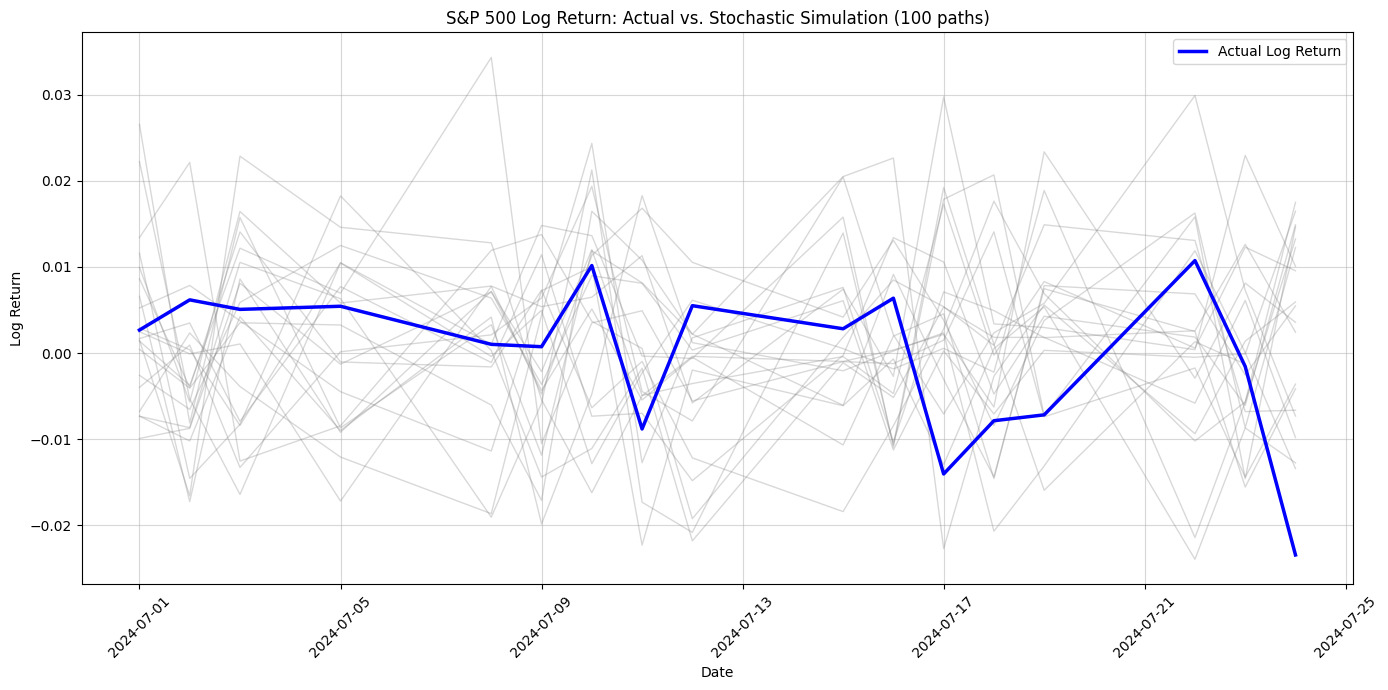

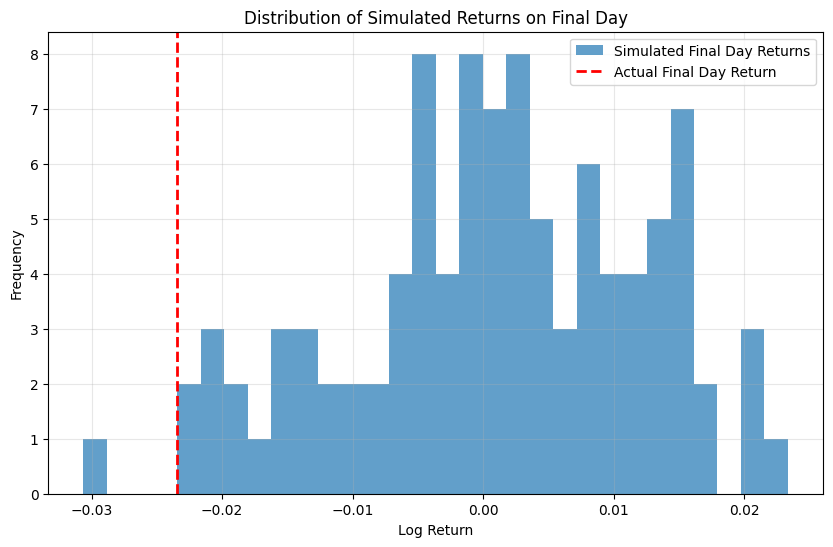

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Prerequisites (Ensure these are available from previous steps) ---
# df: DataFrame after preprocessing, feature engineering, and NaN removal
# log_returns_train: Series of log returns for the training period
# y_last_month: Series containing the actual log returns for the last month
# target: Name of the target column ('Log_Return')

# --- Check if prerequisites exist (Example check) ---
required_vars = ['df', 'log_returns_train', 'y_last_month', 'target']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please ensure the previous code block defining and preparing the data has been run successfully.")
else:
    print("Prerequisites found. Proceeding with stochastic simulation.")

    try:
        # --- 1. Estimate Parameters from Training Data ---
        mu = log_returns_train.mean()
        sigma = log_returns_train.std()
        print(f"\nEstimated Parameters from Training Data:")
        print(f"Mean Daily Log Return (mu):    {mu:.6f}")
        print(f"Std Dev Daily Log Return (sigma): {sigma:.6f}")

        # --- 2. Simulation Setup ---
        # Get the index and number of steps for the last month
        sim_index = y_last_month.index
        n_steps = len(sim_index)
        n_sims = 100 # Number of simulation paths to generate

        if n_steps == 0:
            print("Error: No data points found for the last month to simulate.")
        else:
            print(f"\nSimulation Setup:")
            print(f"Number of steps (days in last month): {n_steps}")
            print(f"Number of simulations: {n_sims}")
            print(f"Simulation period: {sim_index.min()} to {sim_index.max()}")

            # --- 3. Simulate Returns ---
            # Create an array to hold the simulations: rows=days, columns=simulations
            sim_returns_array = np.random.normal(mu, sigma, size=(n_steps, n_sims))

            # Convert to a DataFrame with the correct date index
            sim_returns_df = pd.DataFrame(sim_returns_array, index=sim_index)

            # --- 4. Visualize ---
            print("\n--- Plotting Simulation Results ---")
            plt.figure(figsize=(14, 7))

            # Plot actual returns for the last month
            plt.plot(y_last_month.index, y_last_month, label='Actual Log Return', color='blue', linewidth=2.5, zorder=10) # Make actual line prominent

            # Plot simulated paths
            # Use a loop for clarity, or plot directly from DataFrame
            # Plot only a subset of simulations if n_sims is large to avoid clutter
            plot_sims = min(n_sims, 20) # Plot max 20 simulations
            plt.plot(sim_returns_df.index, sim_returns_df.iloc[:, :plot_sims], color='grey', alpha=0.3, linewidth=1.0, label='_nolegend_') # Plot simulations behind actual

            plt.title(f'S&P 500 Log Return: Actual vs. Stochastic Simulation ({n_sims} paths)')
            plt.xlabel('Date')
            plt.ylabel('Log Return')
            # Manually add legend entry for simulations if needed, or rely on title
            # handles, labels = plt.gca().get_legend_handles_labels()
            # handles.append(plt.Line2D([0], [0], color='grey', alpha=0.5, lw=1))
            # labels.append(f'Simulated Paths ({plot_sims} shown)')
            # plt.legend(handles=handles, labels=labels)
            plt.legend() # Will just show 'Actual Log Return'
            plt.grid(True, alpha=0.5)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            # Optional: Plot histogram of simulated returns at the end vs actual
            plt.figure(figsize=(10, 6))
            plt.hist(sim_returns_df.iloc[-1, :], bins=30, alpha=0.7, label='Simulated Final Day Returns')
            plt.axvline(y_last_month.iloc[-1], color='red', linestyle='dashed', linewidth=2, label='Actual Final Day Return')
            plt.title('Distribution of Simulated Returns on Final Day')
            plt.xlabel('Log Return')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()


    except NameError as ne:
         print(f"A required variable is missing: {ne}")
         print("Please ensure the initial data loading and preparation steps were completed.")
    except Exception as e:
        print(f"An error occurred during simulation: {e}")



GARCH

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 21.8 MB/s eta 0:00:00
Prerequisites found. Proceeding with GARCH simulation.

--- Fitting GARCH(1,1) Model ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9170.67
Distribution:                  Normal   AIC:                           18349.3
Method:            Maximum Likelihood   BIC:                           18376.7
                                        No. Observations:                 6948
Date:                Wed, Apr 30 2025   Df Residuals:                     6947
Time:                        08:56:53   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          

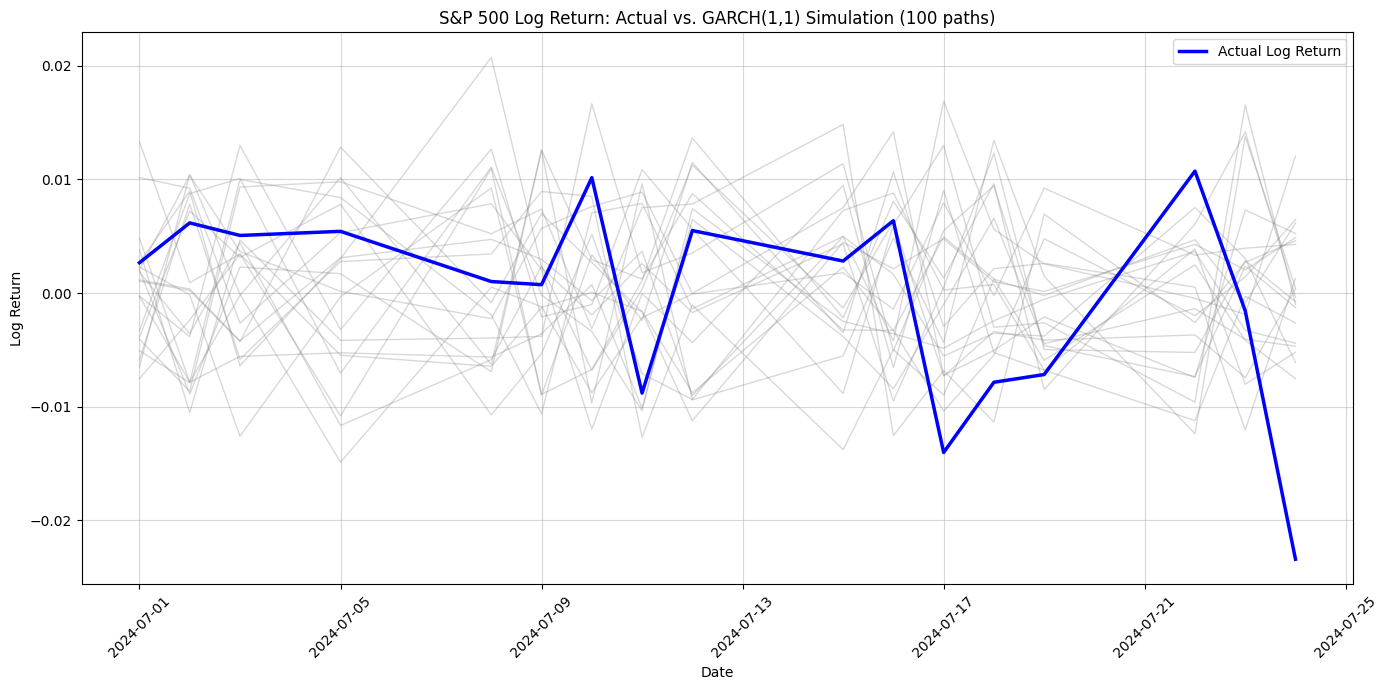

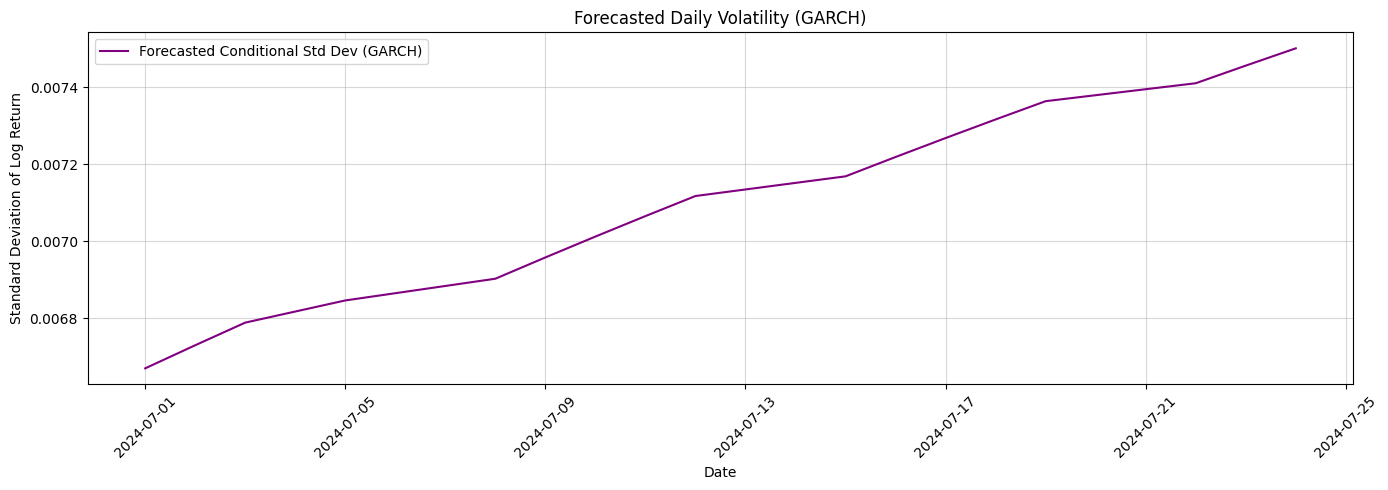

In [17]:
!pip install arch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model # Import the GARCH model function
import warnings

# --- Prerequisites (Ensure these are available from previous steps) ---
# df: DataFrame after preprocessing, feature engineering, and NaN removal
# log_returns_train: Series of log returns for the training period
# y_last_month: Series containing the actual log returns for the last month
# target: Name of the target column ('Log_Return')

# --- Check if prerequisites exist (Example check) ---
required_vars = ['df', 'log_returns_train', 'y_last_month', 'target']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please ensure the previous code block defining and preparing the data has been run successfully.")
else:
    print("Prerequisites found. Proceeding with GARCH simulation.")
    warnings.filterwarnings("ignore") # Suppress convergence warnings etc.

    try:
        # --- 1. Fit GARCH(1,1) Model to Training Data ---
        print("\n--- Fitting GARCH(1,1) Model ---")
        # It's common practice to scale returns by 100 before fitting GARCH
        # This helps with optimization convergence. We'll scale back later.
        scaled_log_returns_train = log_returns_train * 100

        # Define the GARCH(1,1) model
        # p=1, q=1 are the orders for GARCH and ARCH terms
        # vol='Garch': Specifies the GARCH volatility process
        # dist='Normal': Assumes normally distributed errors (can use 't' for Student's t)
        garch = arch_model(scaled_log_returns_train, vol='Garch', p=1, q=1, dist='Normal')

        # Fit the model
        garch_results = garch.fit(update_freq=5, disp='off') # update_freq controls output display
        print(garch_results.summary())

        # --- 2. Forecast Conditional Volatility ---
        print("\n--- Forecasting Conditional Volatility ---")
        # Get the index and number of steps for the last month
        sim_index = y_last_month.index
        n_steps = len(sim_index)
        n_sims = 100 # Number of simulation paths

        if n_steps == 0:
             print("Error: No data points found for the last month to simulate.")
        else:
            print(f"Forecasting volatility for {n_steps} steps (days in last month).")
            # Use the forecast method of the fitted model
            # horizon = number of steps ahead to forecast
            forecast = garch_results.forecast(horizon=n_steps, reindex=False) # reindex=False keeps alignment simple

            # Extract the forecasted conditional variance (h.1 is one-step ahead forecast)
            # The forecast object structure can be complex, check documentation if needed
            # We want the variance forecast for each step up to n_steps
            forecasted_variance = forecast.variance.values.flatten() # Get variance forecasts

            # Convert variance to standard deviation and scale back (divide by 100)
            forecasted_std_dev = np.sqrt(forecasted_variance) / 100.0

            # --- 3. Simulate Returns using GARCH Volatility ---
            print(f"\n--- Simulating {n_sims} Paths using GARCH Volatility ---")
            # Assume conditional mean is zero for simplicity (common for daily returns)
            # Alternatively, use garch_results.params['mu'] / 100 if mean was estimated
            mean_assumption = 0.0

            # Generate standard normal random shocks
            random_shocks = np.random.normal(size=(n_steps, n_sims))

            # Scale shocks by the forecasted time-varying standard deviation
            # Each column (simulation) uses the same volatility forecast for that day
            sim_returns_array = mean_assumption + random_shocks * forecasted_std_dev[:, np.newaxis]

            # Convert to a DataFrame with the correct date index
            sim_returns_df = pd.DataFrame(sim_returns_array, index=sim_index)

            # --- 4. Visualize ---
            print("\n--- Plotting GARCH Simulation Results ---")
            plt.figure(figsize=(14, 7))
            plt.plot(y_last_month.index, y_last_month, label='Actual Log Return', color='blue', linewidth=2.5, zorder=10)

            plot_sims = min(n_sims, 20) # Plot max 20 simulations
            plt.plot(sim_returns_df.index, sim_returns_df.iloc[:, :plot_sims], color='grey', alpha=0.3, linewidth=1.0, label='_nolegend_')

            plt.title(f'S&P 500 Log Return: Actual vs. GARCH(1,1) Simulation ({n_sims} paths)')
            plt.xlabel('Date')
            plt.ylabel('Log Return')
            plt.legend()
            plt.grid(True, alpha=0.5)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            # Optional: Plot the forecasted volatility itself
            plt.figure(figsize=(14, 5))
            plt.plot(sim_index, forecasted_std_dev, label='Forecasted Conditional Std Dev (GARCH)', color='purple')
            plt.title('Forecasted Daily Volatility (GARCH)')
            plt.xlabel('Date')
            plt.ylabel('Standard Deviation of Log Return')
            plt.legend()
            plt.grid(True, alpha=0.5)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    except NameError as ne:
         print(f"A required variable is missing: {ne}")
         print("Please ensure the initial data loading and preparation steps were completed.")
    except ImportError:
        print("Error: The 'arch' library is required. Please install it using: pip install arch")
    except Exception as e:
        print(f"An error occurred during GARCH modeling or simulation: {e}")
        import traceback
        traceback.print_exc() # Print detailed traceback for debugging



Prerequisites found. Proceeding with Student's t-distribution simulation.

--- Fitting Student's t-Distribution ---

Estimated t-Distribution Parameters from Training Data:
Degrees of Freedom (df): 2.0672
Location (loc):          0.000145
Scale (scale):           0.006164

Simulation Setup:
Number of steps (days in last month): 15
Number of simulations: 100
Simulation period: 2017-08-01 00:00:00 to 2017-08-21 00:00:00

--- Simulating 100 Paths using Fitted t-Distribution ---

--- Plotting Simulation Results ---


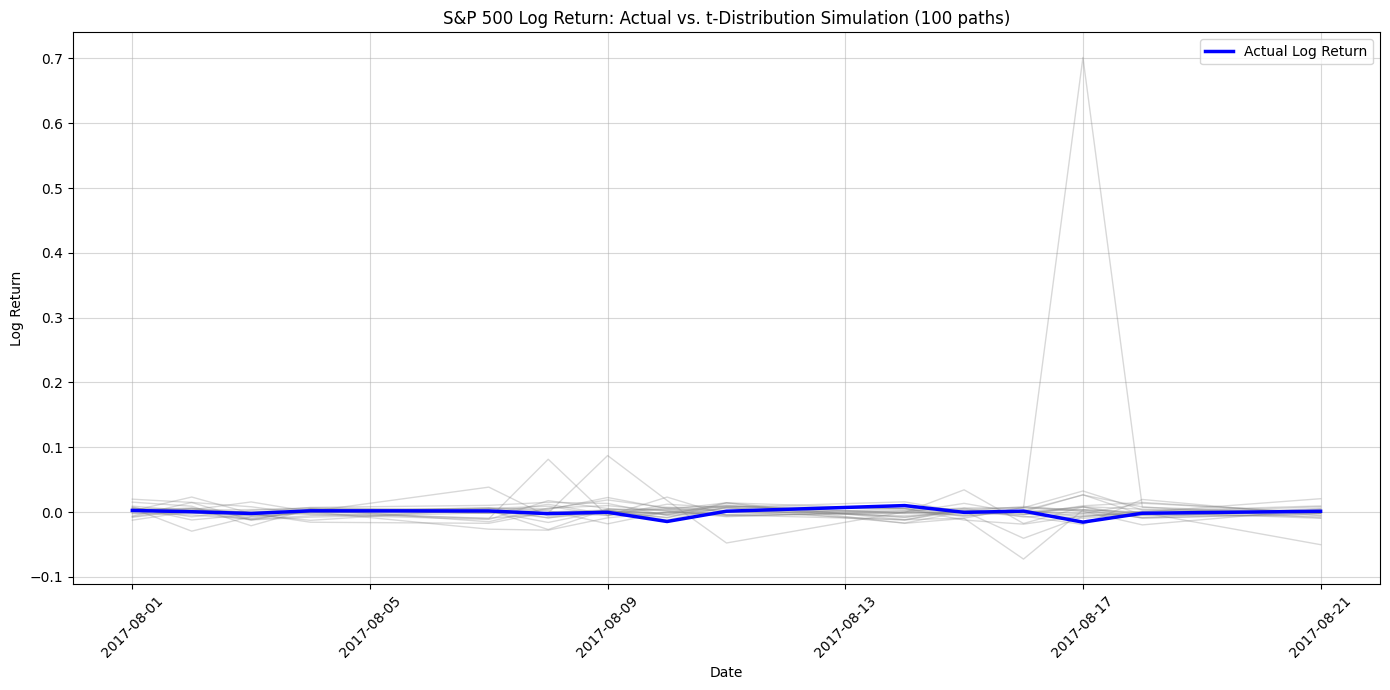

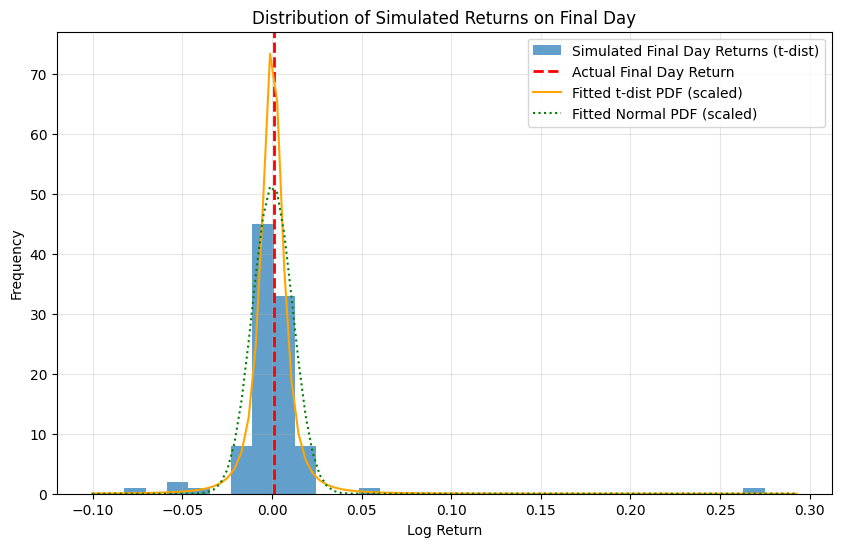

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats # Import stats module from scipy
import warnings

# --- Prerequisites (Ensure these are available from previous steps) ---
# df: DataFrame after preprocessing, feature engineering, and NaN removal
# log_returns_train: Series of log returns for the training period
# y_last_month: Series containing the actual log returns for the last month
# target: Name of the target column ('Log_Return')

# --- Check if prerequisites exist (Example check) ---
required_vars = ['df', 'log_returns_train', 'y_last_month', 'target']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please ensure the previous code block defining and preparing the data has been run successfully.")
else:
    print("Prerequisites found. Proceeding with Student's t-distribution simulation.")
    warnings.filterwarnings("ignore") # Suppress warnings

    try:
        # --- 1. Fit Student's t-Distribution to Training Data ---
        print("\n--- Fitting Student's t-Distribution ---")

        # Use scipy.stats.t.fit to estimate parameters (df, loc, scale)
        # It returns degrees of freedom, location (mean), and scale (related to std dev)
        tdf, tloc, tscale = stats.t.fit(log_returns_train.dropna()) # Drop NaNs just in case

        print(f"\nEstimated t-Distribution Parameters from Training Data:")
        print(f"Degrees of Freedom (df): {tdf:.4f}")
        print(f"Location (loc):          {tloc:.6f}")
        print(f"Scale (scale):           {tscale:.6f}")

        # --- 2. Simulation Setup ---
        # Get the index and number of steps for the last month
        sim_index = y_last_month.index
        n_steps = len(sim_index)
        n_sims = 100 # Number of simulation paths to generate

        if n_steps == 0:
            print("Error: No data points found for the last month to simulate.")
        else:
            print(f"\nSimulation Setup:")
            print(f"Number of steps (days in last month): {n_steps}")
            print(f"Number of simulations: {n_sims}")
            print(f"Simulation period: {sim_index.min()} to {sim_index.max()}")

            # --- 3. Simulate Returns from Fitted t-Distribution ---
            print(f"\n--- Simulating {n_sims} Paths using Fitted t-Distribution ---")
            # Create an array to hold the simulations: rows=days, columns=simulations
            # Use stats.t.rvs to generate random variates from the t-distribution
            sim_returns_array = stats.t.rvs(df=tdf, loc=tloc, scale=tscale, size=(n_steps, n_sims))

            # Convert to a DataFrame with the correct date index
            sim_returns_df = pd.DataFrame(sim_returns_array, index=sim_index)

            # --- 4. Visualize ---
            print("\n--- Plotting Simulation Results ---")
            plt.figure(figsize=(14, 7))

            # Plot actual returns for the last month
            plt.plot(y_last_month.index, y_last_month, label='Actual Log Return', color='blue', linewidth=2.5, zorder=10) # Make actual line prominent

            # Plot simulated paths
            plot_sims = min(n_sims, 20) # Plot max 20 simulations
            plt.plot(sim_returns_df.index, sim_returns_df.iloc[:, :plot_sims], color='grey', alpha=0.3, linewidth=1.0, label='_nolegend_') # Plot simulations behind actual

            plt.title(f'S&P 500 Log Return: Actual vs. t-Distribution Simulation ({n_sims} paths)')
            plt.xlabel('Date')
            plt.ylabel('Log Return')
            plt.legend()
            plt.grid(True, alpha=0.5)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            # Optional: Plot histogram of simulated returns at the end vs actual
            plt.figure(figsize=(10, 6))
            plt.hist(sim_returns_df.iloc[-1, :], bins=30, alpha=0.7, label='Simulated Final Day Returns (t-dist)')
            plt.axvline(y_last_month.iloc[-1], color='red', linestyle='dashed', linewidth=2, label='Actual Final Day Return')
            # Compare with normal distribution fit for context
            norm_mu, norm_std = stats.norm.fit(log_returns_train.dropna())
            x_range = np.linspace(plt.xlim()[0], plt.xlim()[1], 100)
            plt.plot(x_range, stats.t.pdf(x_range, df=tdf, loc=tloc, scale=tscale)*len(sim_returns_df.iloc[-1, :])*(plt.xlim()[1]-plt.xlim()[0])/30, color='orange', label='Fitted t-dist PDF (scaled)')
            plt.plot(x_range, stats.norm.pdf(x_range, loc=norm_mu, scale=norm_std)*len(sim_returns_df.iloc[-1, :])*(plt.xlim()[1]-plt.xlim()[0])/30, color='green', linestyle=':', label='Fitted Normal PDF (scaled)')

            plt.title('Distribution of Simulated Returns on Final Day')
            plt.xlabel('Log Return')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

    except NameError as ne:
         print(f"A required variable is missing: {ne}")
         print("Please ensure the initial data loading and preparation steps were completed.")
    except ImportError:
        print("Error: The 'scipy' library is required. It's usually pre-installed in Colab.")
    except Exception as e:
        print(f"An error occurred during simulation: {e}")
        import traceback
        traceback.print_exc() # Print detailed traceback for debugging

